<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%90%D0%91%D0%9E%D0%A0%D0%90%D0%A2%D0%9E%D0%A0%D0%9D%D0%90_%D0%A0%D0%9E%D0%91%D0%9E%D0%A2%D0%90_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

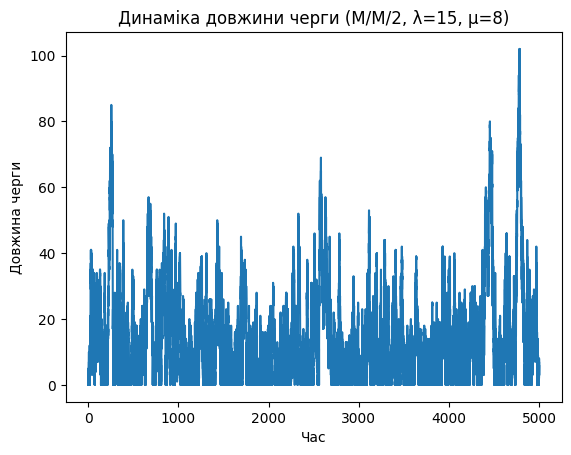

In [2]:
import random
import math
import matplotlib.pyplot as plt

# Параметри системи
lambda_rate = 15
mu = 8
m = 2
SIM_TIME = 5000

def exp_time(rate):
    return -math.log(random.random()) / rate

# Початкові умови
current_time = 0
next_arrival = exp_time(lambda_rate)
next_departures = [float('inf')] * m

queue = []

time_points = []
queue_lengths = []

while current_time < SIM_TIME:

    # найближчa подія
    next_departure = min(next_departures)

    if next_arrival < next_departure:
        #надходження
        current_time = next_arrival
        next_arrival += exp_time(lambda_rate)

        #вільний сервер
        free_servers = [i for i in range(m) if next_departures[i] == float('inf')]

        if free_servers:
            server = free_servers[0]
            service_time = exp_time(mu)
            next_departures[server] = current_time + service_time
        else:
            queue.append(current_time)

    else:
        # Подія: завершення обслуговування
        current_time = next_departure
        server = next_departures.index(next_departure)

        if queue:
            arrival_time = queue.pop(0)
            service_time = exp_time(mu)
            next_departures[server] = current_time + service_time
        else:
            next_departures[server] = float('inf')

    time_points.append(current_time)
    queue_lengths.append(len(queue))

# Побудова графіка
plt.figure()
plt.plot(time_points, queue_lengths)
plt.xlabel("Час")
plt.ylabel("Довжина черги")
plt.title("Динаміка довжини черги (M/M/2, λ=15, μ=8)")
plt.show()